<a href="https://colab.research.google.com/github/Alle84fr/Kim_matemat/blob/05_ap1/AP1_Alessandra_2401151_ADS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dataset = conjunto de dados

Montando o drive (mount):

atalho para google drive do colab

    

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


aba ficheiros aparecerá parasta drive, achar local onde está o arquivo e copiar caminho

este é um caminho loca do colab, que depende da minha conta do google
/content/drive/MyDrive/trabalho_colab_ale/AP1_Alessandra_2401151_ADS.ipynb

usando este caminho quem for ler, terá fileNotfounderor

Pesquisando achei que com link público o professor pode ter acessso pois o colab abaixa os arquivos da internet, salva no /content, que é um diretório volátil, não percistente

https://colab.research.google.com/drive/1t4PwMLa-THg-idGCZeNtYPgj4R4KzYBd?usp=sharing

Pandas - biblioteca para trabalhar com dados

Lê arquivos csv, excel ..., filtra, limpa, faz calulos, etc

df = dataframe = tabela

.head() = mostrar linhas da tabela

In [ ]:
import os

#para ver se o caminho da pasta está correto, e oque está dentro da pasta
os.listdir('/content/drive/MyDrive/trabalho_colab_ale')

['AIDS_Classification.csv',
 'AP1 - analise exploratória de dados.pdf',
 'AP1_Alessandra_2401151_ADS.ipynb']

In [ ]:

!pip install gdown
!gdown "https://drive.google.com/uc?id=1t4PwMLa-THg-idGCZeNtYPgj4R4KzYBd"


Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1t4PwMLa-THg-idGCZeNtYPgj4R4KzYBd

but Gdown can't. Please check connections and permissions.


para acessar dados do file/excel

In [ ]:
# Importar
import pandas as pd

# Ler dados
df = pd.read_csv('/content/drive/MyDrive/trabalho_colab_ale/AIDS_Classification.csv')

df.head()

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
0,948,2,48,89.8128,0,0,0,100,0,0,...,0,1,0,1,0,422,477,566,324,0
1,1002,3,61,49.4424,0,0,0,90,0,1,...,1,3,0,1,0,162,218,392,564,1
2,961,3,45,88.4520,0,1,1,90,0,1,...,1,3,0,1,1,326,274,2063,1893,0
3,1166,3,47,85.2768,0,1,0,100,0,1,...,1,3,0,1,0,287,394,1590,966,0
4,1090,0,43,66.6792,0,1,0,100,0,1,...,1,3,0,0,0,504,353,870,782,0


1° paste:

Fundação dos Dados (Data Cleaning)

Cenário: Você recebeu o dataset bruto e notou que
algumas colunas categóricas (como gênero e raça)
podem estar codificadas de forma que dificultam a
leitura imediata para um relatório.

Além disso, é necessário garantir que não existam valores nulos que
possam distorcer as médias. Tarefa de Codificação:

1. Verifique se existem valores ausentes no dataset e
aplique uma estratégia de limpeza.

2. Certifique-se de que as variáveis age, wtkg (peso) e as contagens de CD4 (cd40, cd420) sejam do tipo numérico (float ou int).

3. Crie uma nova coluna chamada cd4_delta, que representa a variação absoluta na contagem de células CD4 entre o início do estudo e a semana 20

4. O Storytelling: Escreva um parágrafo explicando por
que a limpeza de dados é o "alicerce" de uma análise
clínica confiável. Como um erro de tipo de dado (string em vez de número) poderia levar a conclusões médicas erradas?

isnull() = se existe valor vazio, inexistente
.sum()= soma de todos valores nulos
drop = remover, eliminar
na = Not Available = valor vazio, que são NAN

In [ ]:
#__________ limpando e convertendo

df.isnull().sum()

df = df.dropna()

numericas = ["age", "wtkg", "cd40", "cd420"]

for i in numericas:
  df[i] = pd.to_numeric(df[i], errors="coerce")

df = df.dropna()

#_________________ criando coluna

# subtraindo valor da 1° semna com o da semana 20
df["cd4_delta"] = df['cd420'] - df['cd40']

#_____________ print

# INTEIRRA
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)

#print(df)

# PART (10 1°S)
df.head(10)

,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected,cd4_delta
0,948,2,48,89.8128,0,0,0,100,0,0,...,1,0,1,0,422,477,566,324,0,55
1,1002,3,61,49.4424,0,0,0,90,0,1,...,3,0,1,0,162,218,392,564,1,56
2,961,3,45,88.4520,0,1,1,90,0,1,...,3,0,1,1,326,274,2063,1893,0,-52
3,1166,3,47,85.2768,0,1,0,100,0,1,...,3,0,1,0,287,394,1590,966,0,107
4,1090,0,43,66.6792,0,1,0,100,0,1,...,3,0,0,0,504,353,870,782,0,-151
5,1181,1,46,88.9056,0,1,1,100,0,1,...,3,0,1,0,235,339,860,1060,0,104
6,794,0,31,73.0296,0,1,0,100,0,1,...,3,0,0,0,244,225,708,699,1,-19
7,957,0,41,66.2256,0,1,1,100,0,1,...,3,0,0,0,401,366,889,720,0,-35
8,198,3,40,82.5552,0,1,0,90,0,1,...,3,1,1,1,214,107,652,131,1,-107
9,188,0,35,78.0192,0,1,0,100,0,1,...,3,0,0,1,221,132,221,759,1,-89


STORYTELLING

A limpeza de dados é uma das primeiras fases para analisar dados e transformar-los em infromações.Diminui o volume de linhas e organiza, visualmente as colunas, deixando apenas aquilo que realmente será usado e sem buracos. Já a correção de texto para números, sejam inteiro ou flutuante é fundamental para que posteriormente possamos analisar de forma matemática os dados.

2° O Escudo Imunológico (Box Plots)

Cenário: A diretoria do hospital quer entender a distribuição do peso (wtkg) e da idade (age) entre os pacientes que tiveram sucesso no tratamento vs. aqueles que progrediram para a infecção (infected).

Tarefa de Codificação:

1.Utilize a biblioteca Seaborn ou Matplotlib para gerar dois Box Plots lado a lado.

2.O primeiro gráfico deve mostrar a distribuição de wtkg para os dois grupos de infected.

3.O segundo deve mostrar a distribuição de age para os
mesmos grupos.

4.Identifique visualmente se existem outliers (valores
discrepantes) em algum dos grupos.

5.O Storytelling: Analise as medianas e a dispersão (os "bigodes" do gráfico).

Existe alguma evidência visual de que pacientes mais jovens ou mais leves correm mais risco? O que os outliers nos dizem sobre casos excepcionais na medicina?

TARV - Teprapia Antirretroviral - tratamento com medicamentos para que o HIV, que tem como objetivo impedir a multipluicação do vírus no organismo, reduzindo a carga viral a níveis indectectáveis (para menos de 50 cópiasml).

Supresão viral = pacientes com carga viral indetectáveis, a quantida de vírus no sangue não é vista em testes padrão

Progesso = o TARV não traz resultados no tratamento, a carga viral não desce

/tmp/ipykernel_8235/690776406.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='wtkg', data=df,
/tmp/ipykernel_8235/690776406.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='age', data=df,


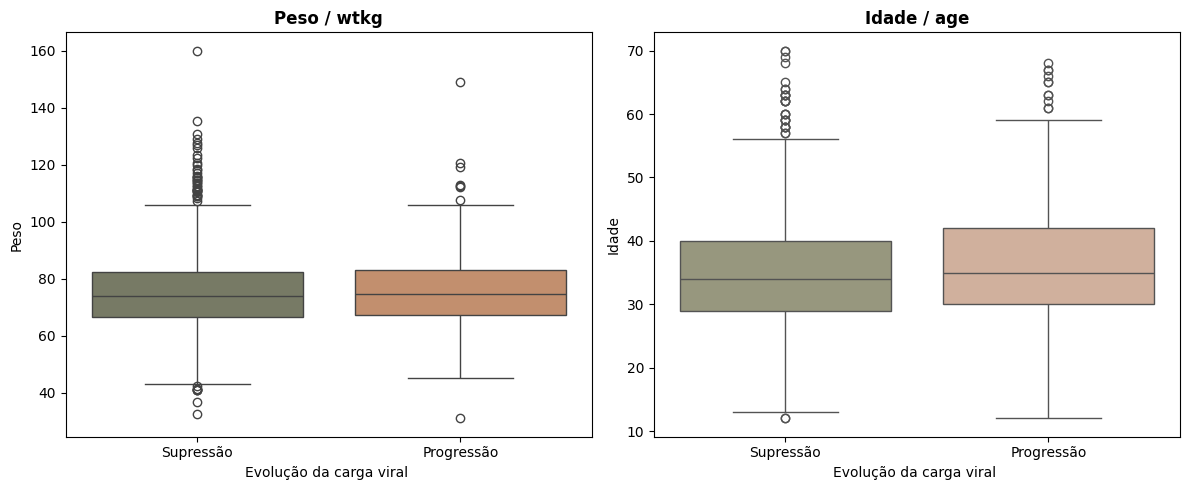

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['status'] = df['infected'].map({
    0: 'Supressão',
    1: 'Progressão'
})

plt.figure(figsize=(12,5))


#______________ KTKG

#lembrando que é 1 linha, duas colunas e 1° gráfico
plt.subplot(1,2,1)

sns.boxplot(x='status', y='wtkg', data=df,
            palette=["#797d62", "#d08c60"])

plt.title("Peso / wtkg", fontsize=12, fontweight="bold")
plt.xlabel("Evolução da carga viral ")
plt.ylabel("Peso")


#______________ AGE

plt.subplot(1,2,2)

sns.boxplot(x='status', y='age', data=df,
            palette=["#9b9b7a", "#d9ae94"])

plt.title("Idade / age", fontsize=12, fontweight="bold")
plt.xlabel("Evolução da carga viral ")
plt.ylabel("Idade")

plt.tight_layout()
plt.show()

In [ ]:

#arrumando dados -  variação absoluta entre semana 1 e 20

df.groupby('status')['cd4_delta'].describe()

#obs - mean = média | std= desvio padrão | Q1 =25 | Q2 / mediana =50 e Q3 = 70% são os quartis | count = soma dos pacientes
# lembrando supe = +
# lembrando progressão = -

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Progressão,521.0,-28.556622,106.127160,-540.0,-91.0,-34.0,36.00,326.0
Supressão,1618.0,36.700865,122.977207,-634.0,-39.0,29.0,103.75,860.0


In [ ]:
# achar o bigode, valor entre a ponta e o retângulo "padrão", o que está fora é outlier
# Q1 - 1.5 e Q3 + 1.5

bigode = df.groupby("status")["cd4_delta"]

Q1 = bigode.quantile(0.25)

Q3 = bigode.quantile(0.75)

#amplitude interquartil
iqr = Q3 - Q1

limite_inferior = Q1 - 1.5 * iqr

limite_superior = Q3 + 1.5 * iqr

print(f"""
limite inferior: {limite_inferior}
limite superior: {limite_superior}
""")


limite inferior: status
Progressão   -281.500
Supressão    -253.125
Name: cd4_delta, dtype: float64
limite superior: status
Progressão    226.500
Supressão     317.875
Name: cd4_delta, dtype: float64



In [ ]:
# início

df.groupby("status")["cd40"].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Progressão,521.0,311.717850,112.894467,110.0,228.0,293.0,387.0,739.0
Supressão,1618.0,362.989493,117.688216,0.0,279.0,353.0,436.0,1199.0


In [ ]:
# semnana 20

df.groupby("status")["cd420"].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Progressão,521.0,283.161228,121.456026,49.0,199.0,265.0,349.0,853.0
Supressão,1618.0,399.690358,140.021798,53.0,299.0,381.0,480.0,1119.0


In [ ]:
# idade

df.groupby("status")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Progressão,521.0,36.328215,9.409986,12.0,30.0,35.0,42.0,68.0
Supressão,1618.0,34.900494,8.444697,12.0,29.0,34.0,40.0,70.0


In [ ]:
# peso

df.groupby("status")["wtkg"].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Progressão,521.0,75.503977,13.043670,31.0000,67.1328,74.7000,83.00880,149.00000
Supressão,1618.0,75.003379,13.334771,32.6592,66.5250,73.9368,82.28442,159.93936


STORYTELLING

Em relação ao peso e à idade, observa-se que a maior parte dos pacientes que não responderam ao tratamento TARV encontra-se entre 30 e 42 anos, com idade  mínima de 12, mesma idade observada nos casos de supressão, e máxima de 68 anos. Em relação ao peso, a maior concentração está entre aproximadamente 67 e 83 kg, embora existam valores fora desse padrão, como 31 kg e até 149 kg.

Entre os pacientes que tiveram supressão viral, a faixa etária predominante está entre 29 e 40 anos, com idade máxima de 70 anos. O peso concentrando-se entre 66 e 82 kg, com mediana, valor "central", de 73,9 kg, fora do padrão foi apresentado pesos de 32 kg à 159 kg.

Comparandor os dois grupos, observa-se que não há diferenças relevantes em relação à idade, já que as distribuições são muito semelhantes. Em relação ao peso, há pequenas variações, porém não suficientes para afirmar que essa variável influencia diretamente a progressão ou a supressão da carga viral.

A variável cd4_delta representa a variação da contagem de células CD4 entre o início do estudo (cd40) e a semana 20 (cd420). A partir dessa análise, observa-se que, dos 2139 pacientes, 521 (24,36%) apresentaram progressão, enquanto 1618 (75,64%) tiveram supressão.

No grupo de progressão, a mediana da variação é de -34, indicando que a maioria dos pacientes apresentou perda de células CD4 (responsável por ativar a produção de anticorpos), ao longo deste período. Além disso, valores
como -540, indicam quedas acentuadas,bem como alguns casos com valores positivos e negativos fora do padrão (-281.500 e 226.500)

O grupo de supressão, a mediana é de 29, indicando maior proteção da células CD4, conseguentemente maior imunidade. Entretanto há variação nos dados, com valores negativos chegando a -634 e positivos chegando a 860. Deixando claro que o resultado depende de cada indivíduo.

Os limites dos “bigodes” indicam a faixa considerada normal dos dados, sendo aproximadamente de -281 a 226 para progressão e de -253 a 317 para supressão. Valores fora desses intervalos são considerados outliers, representando pacientes com respostas muito diferentes do padrão geral.





3° A Eficácia dos Protocolos (Gráficos de
Barras)

Cenário: Existem quatro tratamentos diferentes no
dataset (coluna trt). Precisamos descobrir qual deles
apresenta o melhor desempenho médio na manutenção
das células de defesa.

Tarefa de Codificação:

1. Agrupe os dados pelo tipo de tratamento (trt).

2. Calcule a média da contagem de CD4 na semana 20
(cd420) para cada tratamento.

3. Gere um Gráfico de Barras comparando essas médias.

4. Adicione uma cor diferente para destacar o
tratamento que obteve o melhor resultado (a maior
média).

5. O Storytelling: Imagine que você está apresentando
este gráfico para um comitê de ética médica. Use os
dados para defender o investimento em um dos
protocolos de tratamento específicos.

Como você
explicaria a diferença de performance entre o melhor e
o pior tratamento apenas olhando para as barras?



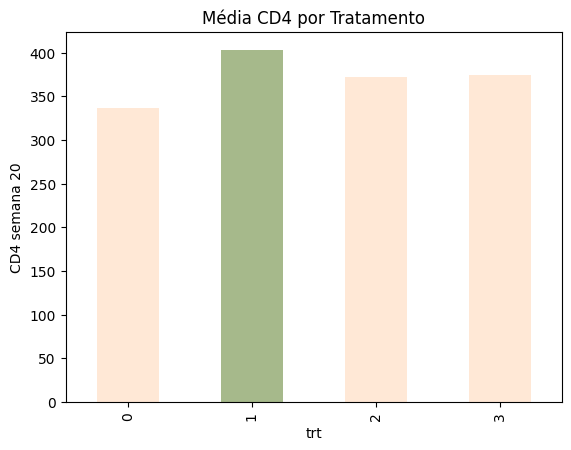

In [ ]:
#media
media_tratamento = df.groupby("trt")["cd420"].mean()

#.idxmax = maior valor de x
melhor = media_tratamento.idxmax()

plt.figure()

cores = ["#ffe8d6" if i != melhor else "#a6b98b" for i in media_tratamento.index]

#.plot() para crira o grafico de barras
media_tratamento.plot(kind='bar', color=cores)

plt.title('Média CD4 por Tratamento')
plt.ylabel('CD4 semana 20')

plt.show()

In [ ]:
# idade

#resumindo
df.groupby("trt")["cd420"].describe()



,count,mean,std,min,25%,50%,75%,max
trt,,,,,,,,
0,532.0,336.139098,130.961573,49.0,243.75,330.5,418.00,909.0
1,522.0,403.172414,156.304065,80.0,285.00,387.0,502.00,1119.0
2,524.0,372.038168,135.030407,52.0,272.00,353.0,458.25,1100.0
3,561.0,374.324421,147.359673,74.0,270.00,356.0,468.00,1040.0


In [ ]:
tratamento_porcen = df.groupby("trt")["cd420"].mean()

trt_1 = tratamento_porcen[1]

trt_3 = tratamento_porcen[3]

trt_1_percen = (trt_1 - trt_3) / trt_3 * 100
print(f"O tratamento 1 tem um eficácia {trt_1_percen:.2f}% maior que o segundo melhor tratamento (2)")

O tratamento 1 tem um eficácia 7.71% maior que o segundo melhor tratamento (2)


In [ ]:
tratamento_porcen = df.groupby("trt")["cd420"].mean()

trt_0 = tratamento_porcen[0]

trt_1_percen = (trt_1 - trt_0) / trt_0 * 100
print(f"O tratamento 1 tem um eficácia {trt_1_percen:.2f}% maior que o último melhor tratamento (0)")

O tratamento 1 tem um eficácia 19.94% maior que o último melhor tratamento (0)


STORYTELLING

O resultado do tratamento na semana 20 mostra que o tratamento 1 apresenta maior eficácia em relação aos demais. Sua média é de aproximadamente 403,12, sendo cerca de 7,71% superior ao tratamento 3 e 19,94% superior ao tratamento com menor desempenho.

Embora as diferenças entre os valores não sejam extremamente elevadas, o fato de o tratamento 1 apresentar a maior média indica uma vantagem em relação aos demais. Isso sugere que uma parcela maior dos pacientes pode ser beneficiada por esse procedimento, ainda que os resultados gerais entre os tratamentos sejam relativamente próximos.

4 Correlações Ocultas (Scatter Plot e
Estatística)

Cenário: Há uma teoria de que a contagem inicial de
CD4 (cd40) é o principal preditor do estado do paciente
após 20 semanas.

Tarefa de Codificação:

1. Crie um Gráfico de Dispersão (Scatter Plot)
relacionando cd40 (eixo X) e cd420 (eixo Y).

2. Utilize o parâmetro hue para colorir os pontos de
acordo com a variável symptom (presença de sintomas).

3. Desafio : O Storytelling: O gráfico mostra uma linha
reta ascendente ou os pontos estão muito espalhados?
Interprete o valor da correlação: se o paciente começa
com um sistema imunológico fraco, o tratamento
consegue reverter isso, ou a tendência é continuar
caindo?

Use a visualização para narrar a "jornada de
recuperação" do paciente médio. Dica para os alunos:

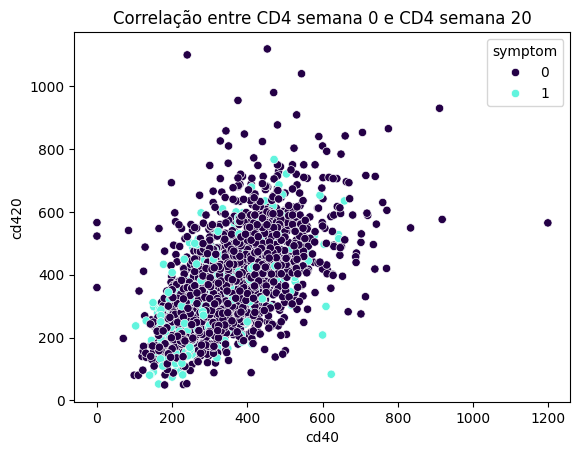

A correlação, relação entre semana 0 e 20 é de 0.584
0 = não possui sintomas e 1 = possui sintomas 


In [ ]:
plt.figure()

sns.scatterplot(
    x="cd40",
    y="cd420",
    hue="symptom",
    data=df,
    palette=["#240046", "#61f4de"]
)

plt.title('Correlação entre CD4 semana 0 e CD4 semana 20')

plt.show()

correlacao = df['cd40'].corr(df['cd420'])

print(f"A correlação, relação entre semana 0 e 20 é de {correlacao:.3f}\n0 = não possui sintomas e 1 = possui sintomas ")

Pensamento ativo sobre diagrama

maioria dos ponto estão concentraos entre 100 e 200 cd4, semana 0 a um pouco menos de 600

já na semana 20 entre 12 talvez e quase 600

o movimento sugere subida diagonal

há pontos outliers cmo um 0 na casa 1200 cd40 levemente abaixo de 600 no cd420

leve dificuldade de traduzir de forma "verbal"


O gráfico de pontos mostra que, ao iniciar o tratamento, os CD4 estão em volumes mais baixos, com poucas dispersões, formando quase que uma ponta arredondada. Há, sim, um outlier, um pouco acima de 600, mas a maioria dos resultados está próxima da casa dos 200.

Conforme passaram-se as semanas, os resultados foram melhorando, levando o gráfico a desenhar uma linha na diagonal ascendente. Outro ponto é que a dispersão dos pontos começou a abrir, mostrando que cada tratamento teve seu resultado específico, não sendo padrão. Porém, na visão geral, o desenvolvimento da imunidade seguiu sem ter muitas variações.

Há, sim, resultados extravagantes, com melhoras muito acima do padrão ou muito abaixo da média. Outro ponto é observar que a maioria dos pacientes não possui sintomas; analisando o diagrama, pode-se dizer que mais da metade dos pacientes está nessa condição.

Já os pontos daqueles que possuem sintomas estão mais concentrados no início, talvez mostrando que, no começo do tratamento, pessoas com e sem sintomas não eram tão discrepantes quanto em comparação com os resultados finais.

STORYTELLING

O gráfico de dispersão mostra que, no início do tratamento, a contagem de CD4 se concentra em valores mais baixos, com menor dispersão, formando uma concentração de pontos principalmente na faixa próxima a 200. Observa-se também a presença de alguns outliers, como valores acima de 600, embora a maioria dos pacientes esteja dentro de um intervalo mais reduzido.

Ao longo das semanas, nota-se uma tendência de crescimento nos valores de CD4, o que faz com que o gráfico apresente um comportamento em diagonal ascendente. Isso indica uma correlação positiva entre os valores iniciais e finais, sugerindo que pacientes que iniciam com níveis mais altos tendem a manter melhores resultados ao longo do tratamento.

Outro ponto relevante é o aumento da dispersão dos dados ao longo do tempo, indicando que a resposta ao tratamento varia entre os pacientes. Isso demonstra que, embora exista uma tendência geral de melhora, os resultados não são uniformes, refletindo diferenças individuais na resposta ao tratamento.

Além disso, há a presença de valores extremos, tanto de melhora significativa quanto de queda acentuada, caracterizando casos fora do padrão geral.

Por fim, ao observar a variável de sintomas, nota-se que a maior parte dos pacientes não apresenta sintomas. Os pacientes sintomáticos tendem a se concentrar mais nas faixas iniciais de CD4, sugerindo que, no início do tratamento, as diferenças entre pacientes com e sem sintomas não são tão acentuadas, mas podem se tornar mais evidentes ao longo do tempo.
